In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data = pd.read_table("sms+spam+collection/SMSSpamCollection",
                     sep="\t",
                     header=None,
                     names=['label', 'messages'])
data.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(data.describe())

       label                messages
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


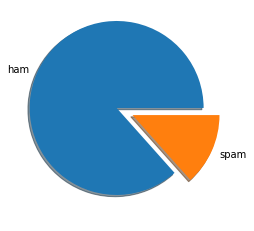

In [6]:
ham_len = len(data['label'][data.label == "ham"])
spam_len = len(data['label'][data.label == "spam"])

arr = np.array([ham_len, spam_len])
labels = ['ham', 'spam']

plt.pie(arr, labels=labels, explode=[0.2,0.0], shadow=True)
plt.show()

In [7]:
#Preprocessing
def text_preprocess(x):
    x = str(x).lower()
    x = x.replace(",000,000", "m").replace(",000", "k").replace(",", "").replace("'", "") \
         .replace("won't", "will not").replace("cannot", "can not").replace("can't", "can not") \
         .replace("n't", " not").replace("what's", "what is").replace("it's", "it is") \
         .replace("'ve", " have").replace("i'm", "i am").replace("'re", " are") \
         .replace("he's", "he is").replace("she's", "she is").replace("'s", " own") \
         .replace("%", " percent").replace("₹", " rupee ").replace("$", " dollar ") \
         .replace("€", " euro ").replace("'ll", " will")

    return x

data["Preprocessed Text"] = data["messages"].apply(lambda x: text_preprocess(x))
data.head()


,label,messages,Preprocessed Text
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy.. available only i...
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [8]:
data['label'] = data.label.map({'ham': 0, 'spam':1})

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['messages'], data['label'], random_state=42)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

count_vector = CountVectorizer()

training_data = count_vector.fit_transform(X_train)

testing_data = count_vector.transform(X_test)

In [12]:
# Model
from sklearn.naive_bayes import MultinomialNB
naive_bayes = MultinomialNB()
naive_bayes.fit(training_data, y_train)

MultinomialNB()

In [13]:
predictions = naive_bayes.predict(testing_data)
predictions

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(format(accuracy_score(y_test, predictions)))

0.9885139985642498


In [15]:
text = "Tho Le is handsome"

def detect(text):
    doc = pd.Series(text)
    num = count_vector.transform(doc)
    pred = naive_bayes.predict(num)
    return pred
labels = ['ham', 'spam']
pred = detect(text)
print(labels[pred[0]])

ham
